In [ ]:
#@title 🎧 Download Narration Audio & Play Introduction
import os as _os
import gdown

# Use a local directory instead of /content (which may be read-only)
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")

if not _os.path.exists(narration_dir):
    try:
        _os.makedirs(narration_dir, exist_ok=True)
        gdown.download(id="1TC_FazSnoHPjHH1jg-Ctr1lWOEnAoZkI", output=f"{narration_dir}/narration.zip", quiet=False)
        !unzip -q {narration_dir}/narration.zip -d {narration_dir}
        !rm {narration_dir}/narration.zip
        print(f"Loaded {len(_os.listdir(narration_dir))} narration segments")
    except Exception as e:
        print(f"⚠️ Could not download narration ({type(e).__name__}: {e})")
        print("This is expected if running locally. Audio narration is optional.")
else:
    print("Narration audio already loaded.")

try:
    from IPython.display import Audio, display
    _f = f"{narration_dir}/01_00_intro.mp3"
    if _os.path.exists(_f):
        display(Audio(_f))
except Exception as e:
    print(f"Audio playback not available: {e}")


In [ ]:
#@title 🎧 Code Walkthrough: Setup Code
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_01_setup_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [1]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU - ROCm/CUDA, Metal (macOS), or CPU
is_rocm = torch.cuda.is_available() and torch.version.hip is not None
if is_rocm:
    device = torch.device('cuda')
    print(f"✅ ROCm GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ CUDA GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"✅ Metal Performance Shaders (MPS) available")
    print(f"   Running on macOS GPU acceleration")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Running on CPU — some cells may run slowly.")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline


✅ Metal Performance Shaders (MPS) available
   Running on macOS GPU acceleration

📦 Python 3.13.12
🔥 PyTorch 2.11.0
🎲 Random seed set to 42


In [ ]:
#@title 🎧 Listen: Notebook Overview
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_02_notebook_overview.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


# Chain-of-Thought Supervised Fine-Tuning -- Vizuara

In this notebook, we will teach a small language model to produce step-by-step reasoning traces using supervised fine-tuning (SFT). By the end, you will have a model that wraps its thinking in `<think>` tags before answering math questions.

**What you will build:** A fine-tuned GPT-2 model that generates chain-of-thought reasoning for grade-school math problems.

In [ ]:
#@title 🎧 Code Walkthrough: Additional Setup
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_03_additional_setup.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [2]:
# GPU check and setup
import torch
print(f"PyTorch version: {torch.__version__}")
is_rocm = torch.cuda.is_available() and torch.version.hip is not None
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"ROCm available: {is_rocm}")
print(f"MPS available: {torch.backends.mps.is_available()}")

if is_rocm:
    print(f"GPU (ROCm): {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
elif torch.cuda.is_available():
    print(f"GPU (CUDA): {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    print(f"GPU: Apple Metal Performance Shaders (MPS)")
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("Running on CPU — training will be slower but still works.")


PyTorch version: 2.11.0
CUDA available: False
MPS available: True
GPU: Apple Metal Performance Shaders (MPS)


In [ ]:
!uv pip install -q transformers datasets accelerate

In [ ]:
#@title 🎧 Listen: Why It Matters
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_04_why_it_matters.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 1. Why Does This Matter?

Large language models like GPT-4 and DeepSeek-R1 can solve complex math problems by "thinking out loud" — generating intermediate reasoning steps before the final answer. But how does a model learn to do this?

The first step is **supervised fine-tuning on chain-of-thought data**. We take a base model and train it on examples where each answer includes step-by-step reasoning. The model learns the *format* of thinking: how to break problems down, how to show its work, and how to structure a logical argument.

By the end of this notebook, you will understand:
- How to format chain-of-thought training data
- How the SFT loss trains on reasoning tokens
- How to fine-tune a small model to produce reasoning traces
- Why SFT alone is necessary but not sufficient

In [ ]:
#@title 🎧 Listen: Building Intuition
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_05_building_intuition.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 2. Building Intuition

Think about how you learned math in school. Your teacher did not just give you answers — they showed you worked examples. Step by step, they demonstrated *how* to solve a problem, and then you practiced on similar problems.

SFT does exactly the same thing for language models. We show the model many worked examples, and it learns to generate similar step-by-step solutions.

The key idea: we wrap the reasoning in special `<think>...</think>` tags so the model knows where the "thinking" starts and ends.

### Think About This
Before we dive in, consider:
- Why might a model that just predicts the answer directly fail on multi-step problems?
- What advantage does "thinking out loud" provide?

In [ ]:
#@title 🎧 Listen: The Mathematics
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_06_the_mathematics.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 3. The Mathematics

The SFT training objective is standard next-token prediction. Given an input sequence, the model learns to predict each token given all previous tokens.

The loss function is the cross-entropy loss over the entire completion sequence (including the reasoning tokens):

$$\mathcal{L}_{\text{SFT}} = -\sum_{t=1}^{T} \log p_\theta(y_t \mid y_{<t}, x)$$

where:
- $x$ is the input prompt
- $y_t$ is the $t$-th token in the target sequence
- $T$ is the total number of tokens (reasoning + answer)
- $\theta$ represents the model parameters

**Computational meaning:** For each position in the sequence, the model outputs a probability distribution over the vocabulary. We take the log probability of the correct next token and sum these up. The negative sum is our loss — lower is better.

In [ ]:
#@title 🎧 Code Walkthrough: Loss Calculation Code
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_07_loss_calculation_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [3]:
# Let us compute this loss manually to build understanding
import torch
import torch.nn.functional as F

# Simulated model probabilities for 4 tokens
# In reality, these come from the model's softmax output
token_probs = torch.tensor([0.8, 0.7, 0.5, 0.9])

# Compute per-token log probabilities
log_probs = torch.log(token_probs)
print("Per-token log probabilities:")
for i, (p, lp) in enumerate(zip(token_probs, log_probs)):
    print(f"  Token {i+1}: p = {p:.1f}, log(p) = {lp:.3f}")

# Compute total loss
total_loss = -log_probs.sum()
avg_loss = total_loss / len(token_probs)
print(f"\nTotal loss: {total_loss:.3f}")
print(f"Average per-token loss: {avg_loss:.3f}")
print(f"\nAs the model gets better, probabilities increase and loss decreases.")

Per-token log probabilities:
  Token 1: p = 0.8, log(p) = -0.223
  Token 2: p = 0.7, log(p) = -0.357
  Token 3: p = 0.5, log(p) = -0.693
  Token 4: p = 0.9, log(p) = -0.105

Total loss: 1.378
Average per-token loss: 0.345

As the model gets better, probabilities increase and loss decreases.


In [ ]:
#@title 🎧 Code Walkthrough: Loading Base Model
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_08_loading_base_model.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 4. Let's Build It -- Component by Component

### 4.1 Loading the Base Model

We will use GPT-2 as our base model. It is small enough to fine-tune on a single GPU but powerful enough to demonstrate chain-of-thought reasoning.

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "gpt2"

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

# GPT-2 does not have a padding token by default
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# Add special tokens for reasoning
special_tokens = {"additional_special_tokens": ["<think>", "</think>"]}
tokenizer.add_special_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"<think> token ID: {tokenizer.convert_tokens_to_ids('<think>')}")
print(f"</think> token ID: {tokenizer.convert_tokens_to_ids('</think>')}")

/Users/pranavr/Developer/Prep/Courses/visuara/reasoning_model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8397.23it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model: gpt2
Parameters: 124,441,344
Vocabulary size: 50259
<think> token ID: 50257
</think> token ID: 50258


In [ ]:
#@title 🎧 Code Walkthrough: Creating Cot Data
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_09_creating_cot_data.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### 4.2 Creating Chain-of-Thought Training Data

For training, we need examples with step-by-step reasoning. Let us create a small dataset of math problems with chain-of-thought solutions.

In [5]:
# Chain-of-thought training examples
cot_examples = [
    {
        "prompt": "What is 15% of 80?",
        "completion": "<think>\nStep 1: 15% means 15/100 = 0.15.\nStep 2: 0.15 * 80 = 12.\nStep 3: Let me verify: 10% of 80 is 8, 5% of 80 is 4, so 15% = 8 + 4 = 12. Correct.\n</think>\nThe answer is 12."
    },
    {
        "prompt": "A store sells pencils for $2 each. If you buy 8 pencils and have a $3 coupon, how much do you pay?",
        "completion": "<think>\nStep 1: Each pencil costs $2. I need 8 pencils.\nStep 2: Total before coupon: 8 * 2 = $16.\nStep 3: Apply $3 coupon: 16 - 3 = $13.\n</think>\nThe answer is $13."
    },
    {
        "prompt": "If a rectangle has length 7 and width 4, what is its area?",
        "completion": "<think>\nStep 1: Area of a rectangle = length * width.\nStep 2: Area = 7 * 4 = 28.\n</think>\nThe answer is 28."
    },
    {
        "prompt": "Tom has 15 apples. He gives 3 to each of his 4 friends. How many does he have left?",
        "completion": "<think>\nStep 1: Tom gives away 3 apples per friend to 4 friends.\nStep 2: Total given away: 3 * 4 = 12 apples.\nStep 3: Remaining: 15 - 12 = 3 apples.\n</think>\nThe answer is 3."
    },
    {
        "prompt": "What is 2^5?",
        "completion": "<think>\nStep 1: 2^5 means 2 multiplied by itself 5 times.\nStep 2: 2 * 2 = 4, 4 * 2 = 8, 8 * 2 = 16, 16 * 2 = 32.\n</think>\nThe answer is 32."
    },
]

# Format for training
def format_example(example):
    return f"Question: {example['prompt']}\n{example['completion']}"

# Show one formatted example
print("=== Formatted Training Example ===")
print(format_example(cot_examples[0]))
print(f"\nTotal examples: {len(cot_examples)}")

=== Formatted Training Example ===
Question: What is 15% of 80?
<think>
Step 1: 15% means 15/100 = 0.15.
Step 2: 0.15 * 80 = 12.
Step 3: Let me verify: 10% of 80 is 8, 5% of 80 is 4, so 15% = 8 + 4 = 12. Correct.
</think>
The answer is 12.

Total examples: 5


In [ ]:
#@title 🎧 Code Walkthrough: Tokenizing Data
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_10_tokenizing_data.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### 4.3 Tokenizing the Training Data

We tokenize the full sequence (prompt + reasoning + answer) and create input-target pairs for next-token prediction.

In [6]:
def tokenize_examples(examples, tokenizer, max_length=256):
    """Tokenize chain-of-thought examples for SFT training."""
    input_ids_list = []
    attention_mask_list = []
    labels_list = []

    for ex in examples:
        text = format_example(ex)
        encoded = tokenizer(
            text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze()
        attention_mask = encoded["attention_mask"].squeeze()

        # Labels are same as input_ids (shifted internally by the model)
        # Set padding tokens to -100 so they are ignored in loss
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        input_ids_list.append(input_ids)
        attention_mask_list.append(attention_mask)
        labels_list.append(labels)

    return {
        "input_ids": torch.stack(input_ids_list),
        "attention_mask": torch.stack(attention_mask_list),
        "labels": torch.stack(labels_list),
    }

# Tokenize our examples
train_data = tokenize_examples(cot_examples, tokenizer)
print(f"Input shape: {train_data['input_ids'].shape}")
print(f"Labels shape: {train_data['labels'].shape}")

# Show the first example decoded
decoded = tokenizer.decode(train_data["input_ids"][0], skip_special_tokens=False)
print(f"\nDecoded first example (first 200 chars):\n{decoded[:200]}")

Input shape: torch.Size([5, 256])
Labels shape: torch.Size([5, 256])

Decoded first example (first 200 chars):
Question: What is 15% of 80?
<think>
Step 1: 15% means 15/100 = 0.15.
Step 2: 0.15 * 80 = 12.
Step 3: Let me verify: 10% of 80 is 8, 5% of 80 is 4, so 15% = 8 + 4 = 12. Correct.
</think>
The answer is


In [ ]:
#@title 🎧 Before You Start: Todo1 Intro
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_11_todo1_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 5. Your Turn -- TODO Exercises

### TODO 1: Implement the SFT Training Loop

Complete the training loop below. You need to:
1. Move the batch to the GPU
2. Forward pass through the model
3. Compute the loss
4. Backpropagate and update

In [ ]:
#@title 🎧 Before You Start: Todo1 Code
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_12_todo1_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [7]:
# Load GSM8K dataset (7,473 real examples)
from datasets import load_dataset
import re

ds = load_dataset("openai/gsm8k", "main")
cot_examples = []

# Use first 100 examples (you can expand to more later)
for example in ds["train"]:
    question = example["question"]
    answer_text = example["answer"]
    
    # GSM8K format: "Step 1: ...\n#### 42"
    # Split on the last #### to separate reasoning from final answer
    parts = answer_text.rsplit("####", 1)
    if len(parts) == 2:
        reasoning = parts[0].strip()
        # Remove calculator annotations like <<48/2=24>>
        reasoning = re.sub(r"<<[^>]+>>", "", reasoning).strip()
        final_answer = parts[1].strip()
        
        cot_examples.append({
            "prompt": question,
            "completion": f"<think>\n{reasoning}\n</think>\nThe answer is {final_answer}."
        })

print(f"✅ Loaded {len(cot_examples)} examples from GSM8K")


Generating test split: 100%|██████████| 1319/1319 [00:00<00:00, 466938.47 examples/s]

✅ Loaded 7473 examples from GSM8K


In [9]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
NUM_EPOCHS = 100  # Small dataset, so we train for many epochs

losses = []

BATCH_SIZE = 16  # Process 16 examples at a time

for epoch in range(NUM_EPOCHS):
    model.train()
    
    # Shuffle data
    indices = torch.randperm(len(train_data['input_ids']))
    
    for i in range(0, len(indices), BATCH_SIZE):
        batch_indices = indices[i:i+BATCH_SIZE]
        batch = {
            k: v[batch_indices].to(device) 
            for k, v in train_data.items()
        }
        
        outputs = model(**batch)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    losses.append(loss.item())  # Track last batch loss

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {loss.item():.4f}")

Epoch 10/100, Loss: 0.5118
Epoch 20/100, Loss: 0.3780
Epoch 30/100, Loss: 0.3523
Epoch 40/100, Loss: 0.2986
Epoch 50/100, Loss: 0.2196
Epoch 60/100, Loss: 0.1828
Epoch 70/100, Loss: 0.1347
Epoch 80/100, Loss: 0.1353
Epoch 90/100, Loss: 0.0884
Epoch 100/100, Loss: 0.0729


In [ ]:
#@title 🎧 Code Walkthrough: Todo1 Verification
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_13_todo1_verification.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [10]:
# Verification: Run this cell to check your training
assert len(losses) == NUM_EPOCHS, f"Expected {NUM_EPOCHS} loss values, got {len(losses)}"
assert losses[-1] < losses[0], f"Loss should decrease! First: {losses[0]:.4f}, Last: {losses[-1]:.4f}"
print(f"Training complete!")
print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")

Training complete!
Initial loss: 0.8019
Final loss: 0.0729
Loss reduction: 90.9%


In [ ]:
#@title 🎧 What to Look For: Visualization Intro
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_14_visualization_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### Visualization Checkpoint: Training Loss Curve

In [ ]:
#@title 🎧 What to Look For: Visualization Code
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_15_visualization_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


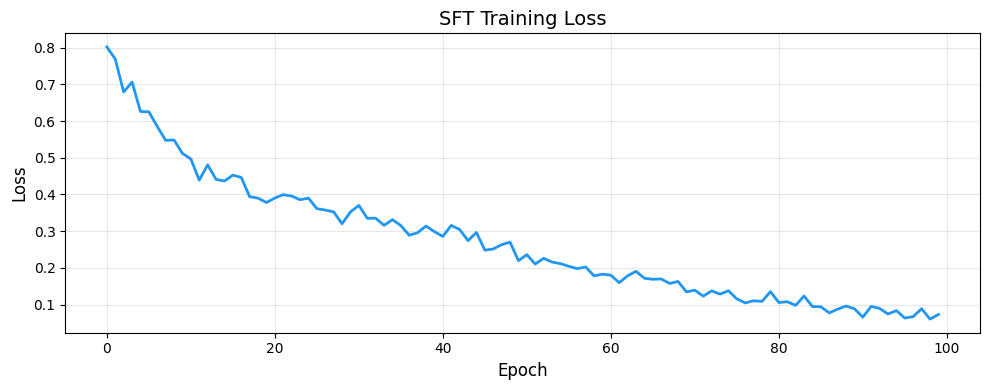

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 4))
plt.plot(losses, color='#2196F3', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('SFT Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#@title 🎧 Code Walkthrough: Putting It Together
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_16_putting_it_together.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 6. Putting It All Together

Now let us test our fine-tuned model. We will give it a math problem and see if it generates a chain-of-thought before answering.

In [12]:
def generate_with_cot(model, tokenizer, question, max_new_tokens=200):
    """Generate a chain-of-thought response from the model."""
    prompt = f"Question: {question}\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=False)
    return response

# Test on training examples
print("=== Testing on Training Examples ===\n")
for ex in cot_examples[:2]:
    response = generate_with_cot(model, tokenizer, ex["prompt"])
    print(f"Q: {ex['prompt']}")
    print(f"Model: {response}")
    print(f"Expected answer: {ex['completion'].split('The answer is')[-1].strip()}")
    print("-" * 60)

=== Testing on Training Examples ===

Q: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Model: Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
<think>
Step 1: Total before coupon: 48 * 48 = 12 apples.
Step 2: Apply $2 coupon: 12 - 3 = $16.
</think>
The answer is 16.
The answer is $16.
Step 3: Apply $2 coupon: 16 - 3 = $13.
The answer is $13.
</think>
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The answer is $13.
The
Expected answer: 72.
-----------------------------------------------------

In [ ]:
#@title 🎧 Before You Start: Todo2 Intro
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_17_todo2_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### TODO 2: Test on New Problems

Test the model on problems it has not seen during training. Does it generalize?

In [ ]:
#@title 🎧 Before You Start: Todo2 Code
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_18_todo2_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [13]:
# ============ TODO ============
# Create 3 new math problems and test the model on them.
# Observe whether the model produces <think> tags and
# whether the reasoning is correct.
#
# new_questions = [
#     "What is 25% of 200?",
#     ???,
#     ???,
# ]
#
# for q in new_questions:
#     response = generate_with_cot(model, tokenizer, q)
#     print(f"Q: {q}")
#     print(f"Model: {response}\n")
# ==============================

new_questions = [
    "What is 25% of 200",
    "What is a 1/4 of 2000"

]
for q in new_questions:
    response = generate_with_cot(model, tokenizer, q)
    print(f"Q: {q}")
    print(f"Model: {response}\n")

Q: What is 25% of 200
Model: Question: What is 25% of 200
<think>
Step 1: 25% means 25/100 = 0.25.
Step 2: 0.25 * 200 = 12.
Step 3: Let me verify: 10% of 200 is 8, 5% of 200 is 4, so 25% = 8 + 4 = 12. Correct.
</think>
The answer is 12. Correct.
The answer is 12.
Step 4: Let me verify: 10% of 200 is 8, 5% of 200 is 4, so 25% = 8 + 4 = 12. Correct.
<think>
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The

Q: What is a 1/4 of 2000
Model: Question: What is a 1/4 of 2000
<think>
Step 1: A 1/4 = 0.15.
Step 2: 0.15 * 2000 = 12.
Step 3: Let me verify: 10% of 80 is 8, 5% of 80 is 4, so 15% = 8 + 4 = 12. Correct.
</think>
The answer is 12.
The answer is 12. Correct.
</think>
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer is 12.
The answer

In [ ]:
#@title 🎧 Code Walkthrough: Analysis
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_19_analysis.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 7. Training and Results

Let us analyze what the model learned.

In [14]:
# Analyze the generated outputs
print("=== Analysis of Model Behavior ===\n")

test_questions = [
    "What is 20% of 50?",
    "If you have 10 cookies and eat 3, how many are left?",
    "What is 6 times 7?"
]

for q in test_questions:
    response = generate_with_cot(model, tokenizer, q)
    has_think = "<think>" in response and "</think>" in response
    print(f"Q: {q}")
    print(f"Has <think> tags: {has_think}")
    print(f"Response: {response[:300]}")
    print("-" * 60)

=== Analysis of Model Behavior ===

Q: What is 20% of 50?
Has <think> tags: True
Response: Question: What is 20% of 50?
</think>
Step 1: 20% means 20/100 = 0.20.
Step 2: 0.20 * 50 = 12.
Step 3: Let me verify: 10% of 50 is 8, 5% of 50 is 4, so 15% = 8 + 4 = 12. Correct.
</think>
The answer is 12.
The answer is 12.
Step 1: Let me verify: 10% of 50 is 8, 5% of 50 is 4, so 15% = 8 + 4 = 12. C
------------------------------------------------------------
Q: If you have 10 cookies and eat 3, how many are left?
Has <think> tags: False
Response: Question: If you have 10 cookies and eat 3, how many are left?
<think>
Step 1: Each cookie costs 3 calories.
Step 2: Total before serving: 3 * 2 = 12.
Step 3: Remaining: 15 - 12 = 3.
<think>
The answer is 3.
The answer is 3.
The answer is 3.
Step 1: Total before serving: 3 * 2 = 12.
Step 2: Remainin
------------------------------------------------------------
Q: What is 6 times 7?
Has <think> tags: True
Response: Question: What is 6 times 7?
<think>
Ste

In [ ]:
#@title 🎧 Listen: Final Output
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_20_final_output.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 8. Final Output

Our SFT-trained model can now produce chain-of-thought reasoning traces. However, notice the limitations:
- The model learns the *format* of reasoning (using `<think>` tags)
- But the *quality* of reasoning is limited to mimicking the training examples
- On novel problems, the reasoning may be plausible-looking but incorrect

This is exactly why we need reinforcement learning (covered in Notebook 2) — to teach the model which reasoning strategies actually lead to correct answers.

In [ ]:
#@title 🎧 Wrap-Up: Reflection Next Steps
from IPython.display import Audio, display
import os as _os
narration_dir = _os.path.expanduser("~/Developer/Prep/Courses/visuara/reasoning_model/narration")
_f = f"{narration_dir}/01_21_reflection_next_steps.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## 9. Reflection and Next Steps

### Think About This
1. Why does SFT alone teach format but not quality?
2. What would happen if we trained on millions of CoT examples instead of 5?
3. How is this similar to / different from how humans learn to solve math problems?

### What Comes Next
In Notebook 2, we will implement GRPO (Group Relative Policy Optimization) from scratch — the RL algorithm that teaches a model to reason *well*, not just to reason *plausibly*.

### Key Takeaway
SFT is the foundation of reasoning model training. It teaches the model the structure of step-by-step thinking. But structure without correctness is not enough — that is where reinforcement learning comes in.